C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.200548
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Con

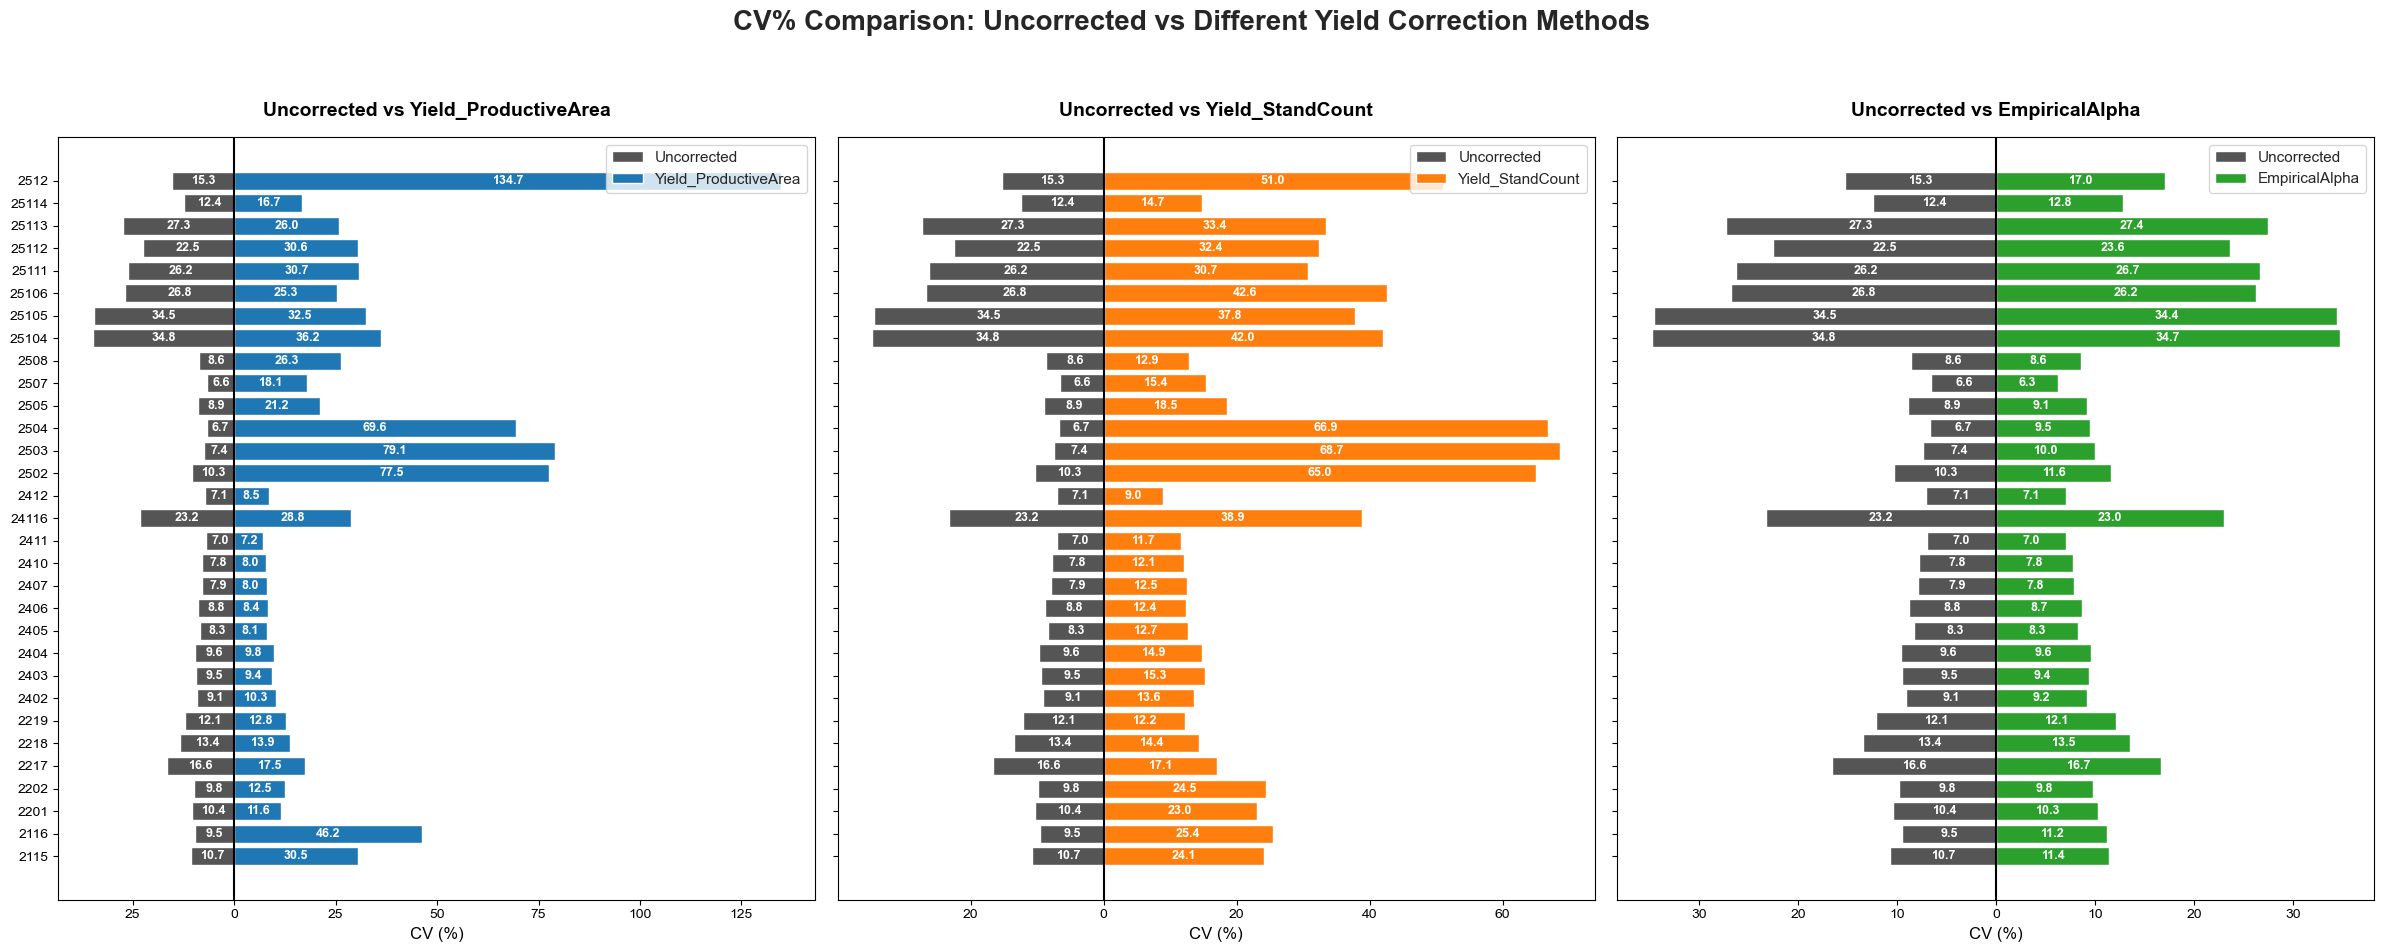

Analysis complete. Tornado plots comparing 3 methods generated.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated_with_rescaled_yields.xlsx"

df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()

# Define the methods to compare against Uncorrected yield
correction_methods = ['Yield_ProductiveArea', 'Yield_StandCount', 'EmpiricalAlpha']

# Ensure categorical types for factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            # Mixed Linear Model
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            # Fallback to OLS
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
# We store the CV results for each method in a dictionary
results_dict = {}

for exp_name, exp_data in df.groupby('Experiment Name'):
    # Always calculate Uncorrected CV as the baseline
    _, _, u_cv = calculate_metrics(exp_data, 'Uncorrected_Yield')
    
    if np.isnan(u_cv):
        continue
        
    trial_results = {'Trial': exp_name, 'Uncorrected_CV': u_cv}
    
    for method in correction_methods:
        _, _, m_cv = calculate_metrics(exp_data, method)
        trial_results[f'{method}_CV'] = m_cv
        
    results_dict[exp_name] = trial_results

results_df = pd.DataFrame.from_dict(results_dict, orient='index').reset_index(drop=True)

# --- VISUALIZATION (MULTI-METHOD TORNADO) ---
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)
sns.set_theme(style="white")

def plot_cv_tornado(ax, method_col, method_name, color_r):
    # Filter out trials that might be missing this specific method
    plot_data = results_df.dropna(subset=['Uncorrected_CV', method_col])
    
    # Tornado logic: Negative for Uncorrected (left), Positive for Corrected (right)
    ax.barh(plot_data['Trial'], -plot_data['Uncorrected_CV'], color='#555555', label='Uncorrected')
    ax.barh(plot_data['Trial'], plot_data[method_col], color=color_r, label=method_name)
    
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(f"Uncorrected vs {method_name}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("CV (%)", fontsize=12)
    
    # Add labels inside bars
    for i, (u, m) in enumerate(zip(plot_data['Uncorrected_CV'], plot_data[method_col])):
        ax.text(-u/2, i, f"{u:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=9)
        ax.text(m/2, i, f"{m:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=9)
    
    # Absolute value ticks
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
    ax.legend(loc='upper right')

# Colors for each method
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, method in enumerate(correction_methods):
    plot_cv_tornado(axes[i], f'{method}_CV', method, colors[i])

plt.suptitle("CV% Comparison: Uncorrected vs Different Yield Correction Methods", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Yield_Correction_Methods_Comparison91.png', dpi=300)
plt.show()

print(f"Analysis complete. Tornado plots comparing {len(correction_methods)} methods generated.")

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may

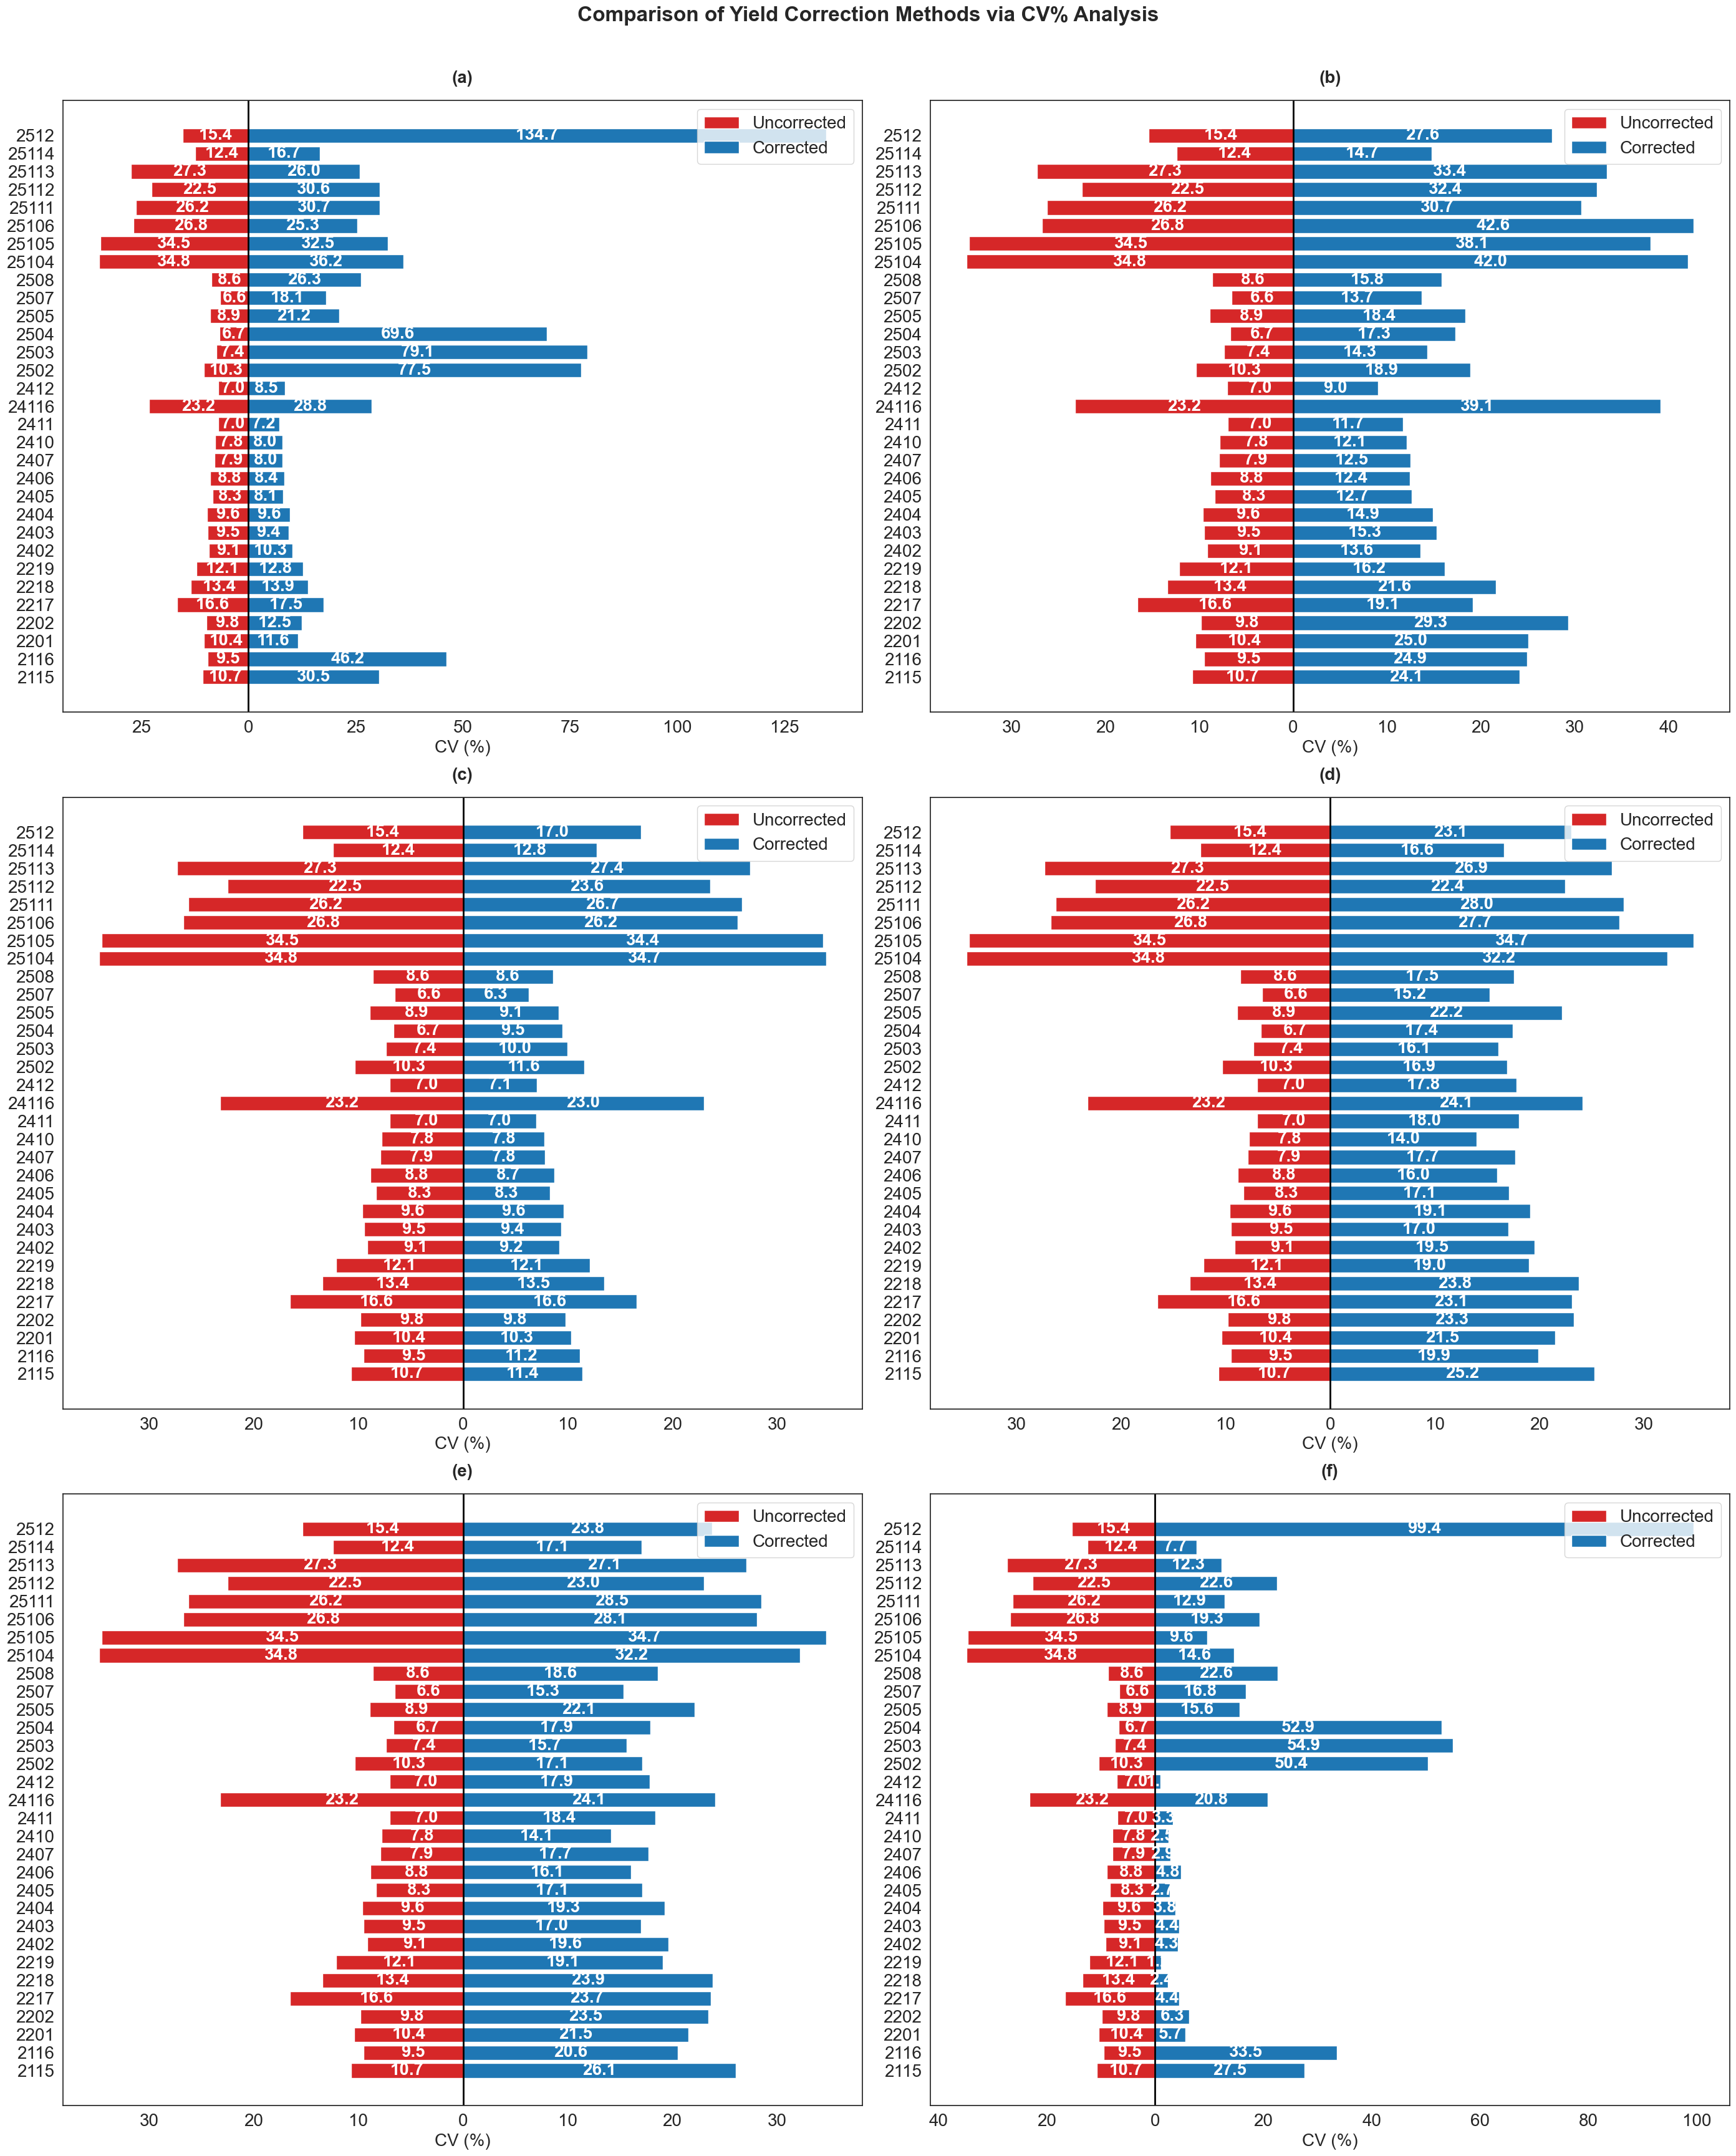

Analysis complete. 6-panel tornado plot generated.


In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated_with_rescaled_yields.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Updated methods list matching your new Excel columns
correction_methods = [
    'Yield_ProductiveArea', 'Yield_StandCount', 'EmpiricalAlpha',
    'PowerLaw', 'non_linear', 'geostatistical'
]

# Mapping for titles
titles_map = {
    'Yield_ProductiveArea': '(a)',
    'Yield_StandCount': '(b)',
    'EmpiricalAlpha': '(c)',
    'PowerLaw': '(d)',
    'non_linear': '(e)',
    'geostatistical': '(f)'
}

# Ensure categorical types
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
results_dict = {}
for exp_name, exp_data in df.groupby('Experiment Name'):
    _, _, u_cv = calculate_metrics(exp_data, 'Uncorrected_Yield')
    if np.isnan(u_cv):
        continue
        
    trial_results = {'Trial': exp_name, 'Uncorrected_CV': u_cv}
    for method in correction_methods:
        if method in df.columns:
            _, _, m_cv = calculate_metrics(exp_data, method)
            trial_results[f'{method}_CV'] = m_cv
        
    results_dict[exp_name] = trial_results

results_df = pd.DataFrame.from_dict(results_dict, orient='index').reset_index(drop=True)

# --- VISUALIZATION (6 SUBFIGURES) ---
fig, axes = plt.subplots(3, 2, figsize=(28, 36))
axes = axes.flatten()
sns.set_theme(style="white")

def plot_cv_tornado(ax, method_col, method_key):
    method_name = titles_map[method_key]
    plot_data = results_df.dropna(subset=['Uncorrected_CV', method_col])
    
    # Tornado logic: Red for Uncorrected (left), Blue for Corrected (right)
    ax.barh(plot_data['Trial'], -plot_data['Uncorrected_CV'], color='#d62728', label='Uncorrected')
    ax.barh(plot_data['Trial'], plot_data[method_col], color='#1f77b4', label='Corrected')
    
    ax.axvline(0, color='black', linewidth=2)
    ax.set_title(method_name, fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel("CV (%)", fontsize=20)
    
    # Labels inside bars
    for i, (u, m) in enumerate(zip(plot_data['Uncorrected_CV'], plot_data[method_col])):
        ax.text(-u/2, i, f"{u:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=20)
        ax.text(m/2, i, f"{m:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=20)
    
    # Formatting ticks
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks], fontsize=20)
    plt.setp(ax.get_yticklabels(), fontsize=20)
    ax.legend(loc='upper right', fontsize=20)

for i, method in enumerate(correction_methods):
    plot_cv_tornado(axes[i], f'{method}_CV', method)

plt.suptitle("Comparison of Yield Correction Methods via CV% Analysis", fontsize=24, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig('Yield_Correction_6Panel_Comparison.png', dpi=300)
plt.show()

print("Analysis complete. 6-panel tornado plot generated.")